# Simulation-Based Inference for Time Series Data

This notebook demonstrates simulation-based inference (SBI) for time series data using neural posterior estimation (NPE) with time-series embeddings. We'll use a physically-motivated example: a damped harmonic oscillator.

NOTE: I replaced this Claude-generated esxample with the Ricker model.

Based on the tutorial at https://sbi.readthedocs.io/en/latest/how_to_guide/20_time_series_embedding.html

## The Problem

We want to infer the parameters of a damped harmonic oscillator from observed time series data:
- **ω₀**: Natural frequency
- **γ**: Damping coefficient
- **A**: Initial amplitude

Given noisy observations of the oscillator's position over time, we'll use SBI to recover the posterior distribution over these parameters.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
import os
from pathlib import Path

from bettercode.utils import save_fig

IMAGE_DIR = Path('../../latex/figures')
CHAPTER = 9

# Configuration
make_plots = False  # Set to False to disable plotting (useful for headless/script mode)

from sbi.inference import NPE
from sbi.neural_nets import embedding_nets, posterior_nn
from sbi.utils import BoxUniform

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Define device for computations
# Note: SBI has some operations (like unique_dim) not yet implemented for MPS
# Using CPU is more reliable, but you can try "cuda" if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("Note: Using CPU for reliable SBI operations. MPS (Apple Silicon GPU) has limited support.")

Using device: cpu
Note: Using CPU for reliable SBI operations. MPS (Apple Silicon GPU) has limited support.


## Step 1: Define the Simulator

We'll simulate a damped harmonic oscillator with the equation:

$$x(t) = A e^{-\gamma t} \cos(\omega t)$$

where:
- $\omega = \sqrt{\omega_0^2 - \gamma^2}$ is the damped frequency
- $A$ is the initial amplitude
- $\gamma$ is the damping coefficient
- $\omega_0$ is the natural frequency

We'll add Gaussian noise to make the problem realistic.

In [2]:
def damped_oscillator_simulator(theta, t=None, noise_std=0.05):
    """
    Simulate a damped harmonic oscillator.
    
    Parameters:
    -----------
    theta : torch.Tensor, shape (batch_size, 3)
        Parameters [omega_0, gamma, amplitude]
        - omega_0: natural frequency (0.5 to 3.0 rad/s)
        - gamma: damping coefficient (0.1 to 1.0)
        - amplitude: initial amplitude (0.5 to 2.0)
    t : torch.Tensor or None
        Time points. If None, use 100 points from 0 to 10.
    noise_std : float
        Standard deviation of Gaussian noise
        
    Returns:
    --------
    x : torch.Tensor, shape (batch_size, n_timesteps)
        Simulated time series
    """
    if t is None:
        t = torch.linspace(0, 10, 100)
    
    # Handle both single parameter set and batches
    if theta.ndim == 1:
        theta = theta.unsqueeze(0)
    
    omega_0 = theta[:, 0:1]  # shape (batch_size, 1)
    gamma = theta[:, 1:2]
    amplitude = theta[:, 2:3]
    
    # Damped frequency
    omega = torch.sqrt(torch.clamp(omega_0**2 - gamma**2, min=0.01))
    
    # Time series: A * exp(-gamma*t) * cos(omega*t)
    t = t.unsqueeze(0)  # shape (1, n_timesteps)
    x = amplitude * torch.exp(-gamma * t) * torch.cos(omega * t)
    
    # Add Gaussian noise
    noise = torch.randn_like(x) * noise_std
    x = x + noise
    
    return x.squeeze(0) if theta.shape[0] == 1 else x


def ricker_model_with_k(N, r, k, sigma=0.3, phi=10):
    """
    Ricker model with environmental and demographic stochasticity.
    Defaults from Wood, 2010, Nature
    Parameters:
    N : float
        Current population size.
    r : float
        Intrinsic growth rate.
    k : float
        Carrying capacity.
    sigma : float
        Growth rate variability (normally distributed).
    phi : float
        Measurement error term (Poisson distributed).

    Returns:
    N_next : float
        Next population size.
    """
    N_next = N * np.exp(r * (1 - (N/k)) + np.random.normal(0, sigma))
    y_next = np.random.poisson(N_next * phi)
    return N_next, y_next



def ricker_model(N, r, sigma=0.3, phi=10):
    """
    Ricker model with stochasticity.
    Defaults from Wood, 2010, Nature
    Parameters:
    N : float
        Current population size.
    r : float
        Intrinsic growth rate.
    sigma : float
        Growth rate variability (normally distributed).
    phi : float
        Measurement error term (Poisson distributed).

    Returns:
    N_next : float
        Next population size.
    """
    N_next = r * N * np.exp(-N + np.random.normal(0, sigma))
    y_next = np.random.poisson(N_next * phi)
    return N_next, y_next


def ricker_simulator(params: torch.Tensor, t=None, n_time_steps=250, starting_n=100):
    # 
    r = params[0].cpu().numpy()  # intrinsic growth rate
    sigma = params[1].cpu().numpy()  # growth rate variability
    phi = params[2].cpu().numpy()      # measurement error term
    
    if t is None:
        t = torch.linspace(0, 1, n_time_steps)

    # use a random proportion of carrying capacity as initial population size
    N = starting_n 
    timeseries = []
    for t in range(n_time_steps):
        N, y = ricker_model(N, r, sigma, phi)
        timeseries.append(y)
    # return only y values
    return torch.as_tensor(np.array(timeseries), dtype=torch.float32)  

## Step 2: Test the Simulator

Let's visualize a few sample time series with different parameters.

In [3]:
# Test the simulator with different parameter combinations
t = torch.linspace(0, 10, 250)

if make_plots:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    test_params = [
        torch.tensor([np.exp(3.8), 0.3, 10]), 
        torch.tensor([np.exp(2), 0.3, 10]),  
        torch.tensor([np.exp(3.8), 0.5, 10]),  
        torch.tensor([np.exp(3.8), 0.3, 5]),  
    ]

    for i, params in enumerate(test_params):
        x = ricker_simulator(params, t=t)
        axes[i].plot(t.numpy(), x.numpy(), linewidth=2)
        axes[i].set_xlabel('Time (s)')
        axes[i].set_ylabel('Position')
        axes[i].set_title(f'ω₀={params[0]:.1f}, γ={params[1]:.1f}, A={params[2]:.1f}')
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("Simulator test complete!")

Simulator test complete!


## Step 3: Define Prior and Generate Training Data

We'll define uniform priors over the parameter ranges and generate training data by simulating many time series.

In [4]:
# Define prior distributions based on parameter ranges
# r (intrinsic growth rate): [1, 100]
# sigma (growth rate variability): [0.1, 5]
# phi (measurement error term): [1, 50]
prior = BoxUniform(
    low=torch.tensor([1, 0.1, 1], device=device),
    high=torch.tensor([100, 5, 50], device=device),
    device=device
)

# Generate training data
n_simulations = 2000
print(f"Generating {n_simulations} simulations for training...")
print(f"Using device: {device}")

thetas = prior.sample((n_simulations,))
xs = torch.stack([ricker_simulator(theta) for theta in thetas]).to(device)

print(f"Training data shape: {xs.shape}")
print(f"Parameters shape: {thetas.shape}")
print(f"Parameter ranges:")
print(f"  r: [{thetas[:, 0].min():.2f}, {thetas[:, 0].max():.2f}]")

print(f"  sigma:  [{thetas[:, 1].min():.2f}, {thetas[:, 1].max():.2f}]")
print(f"  phi:  [{thetas[:, 2].min():.2f}, {thetas[:, 2].max():.2f}]")

Generating 2000 simulations for training...
Using device: cpu
Training data shape: torch.Size([2000, 250])
Parameters shape: torch.Size([2000, 3])
Parameter ranges:
  r: [1.36, 99.96]
  sigma:  [0.11, 5.00]
  phi:  [1.05, 49.96]


## Step 4: Create "Observed" Data

Generate a synthetic observation with known parameters that we'll try to recover.

In [5]:
# True parameters for our "observation"
true_theta = torch.tensor([44, 0.3, 10])
x_obs = ricker_simulator(true_theta).to(device)

print(f"True parameters: r={true_theta[0]:.2f}, K={true_theta[1]:.2f}")
print(f"Observation tensor device: {x_obs.device}")

# Visualize the observation
if make_plots:
    plt.figure(figsize=(10, 4))
    plt.plot(t.numpy(), x_obs.cpu().numpy(), linewidth=2, color='darkblue')
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Position', fontsize=12)
    plt.title('Observed Time Series', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

True parameters: r=44.00, K=0.30
Observation tensor device: cpu


## Step 5: Build Neural Posterior Estimator with CausalCNN Embedding

We'll use a Causal CNN embedding network to extract temporal features from the time series, then train a neural posterior estimator.

In [6]:
# Define a causal CNN embedding for 1D time-series data
embedding_cnn = embedding_nets.CausalCNNEmbedding(
    input_shape=(250,),      # Time series length
    num_conv_layers=4,       # Number of convolutional layers
    pool_kernel_size=8,      # Pooling window for temporal downsampling
    output_dim=20,           # Embedding dimension
).to(device)

# Define a Transformer embedding for capturing global dependencies
# Based on the tutorial: https://sbi.readthedocs.io/en/latest/how_to_guide/20_time_series_embedding.html
class TransformerEmbedding(nn.Module):
    """Transformer-based embedding for time series with global attention."""
    def __init__(self, input_dim=1, d_model=64, nhead=4, num_layers=2, 
                 dim_feedforward=128, output_dim=20, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        # Input projection
        self.input_projection = nn.Linear(input_dim, d_model)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Output projection
        self.fc = nn.Linear(d_model, output_dim)
        
    def forward(self, x):
        # x shape: (batch_size, sequence_length)
        # Reshape to (batch_size, sequence_length, 1) for transformer
        x = x.unsqueeze(-1)
        
        # Project to d_model dimensions
        x = self.input_projection(x) * np.sqrt(self.d_model)
        
        # Add positional encoding
        x = self.pos_encoder(x)
        
        # Transformer encoding
        x = self.transformer(x)
        
        # Global average pooling over sequence dimension
        x = x.mean(dim=1)  # shape: (batch_size, d_model)
        
        # Project to output dimension
        x = self.fc(x)  # shape: (batch_size, output_dim)
        
        return x

class PositionalEncoding(nn.Module):
    """Positional encoding for transformer."""
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Create positional encoding matrix
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

embedding_transformer = TransformerEmbedding(
    input_dim=1,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    output_dim=20,
    dropout=0.1
).to(device)

# Build density estimators with different embeddings
# Using MAF (Masked Autoregressive Flow) for flexible posterior
# Note: z_score_theta controls parameters, z_score_x controls the data/observations
# (older sbi releases called these z_score_x / z_score_y respectively).

# 1. CausalCNN: Best for local temporal patterns
density_estimator_cnn = posterior_nn(
    model="maf",
    embedding_net=embedding_cnn,
    z_score_theta="none",
    z_score_x="none",
)

# 2. Transformer: Captures global dependencies via self-attention
density_estimator_transformer = posterior_nn(
    model="maf",
    embedding_net=embedding_transformer,
    z_score_theta="none",
    z_score_x="none",
)

# Use CNN embedding as default (best for this problem)
#density_estimator = density_estimator_transformer
density_estimator = density_estimator_cnn

print("Neural network architectures created successfully!")
print("  - CausalCNN embedding: for local temporal patterns (DEFAULT)")
print("  - Transformer embedding: for global dependencies via self-attention")
print("\nNote: Change 'density_estimator' variable to try different embeddings")
print("      e.g., density_estimator = density_estimator_transformer")

(16, 31)
(64, 15)
(20, 7)
Neural network architectures created successfully!
  - CausalCNN embedding: for local temporal patterns (DEFAULT)
  - Transformer embedding: for global dependencies via self-attention

Note: Change 'density_estimator' variable to try different embeddings
      e.g., density_estimator = density_estimator_transformer


## Step 6: Train the Neural Posterior Estimator

This step trains the neural network to learn the mapping from time series to posterior distributions over parameters.

In [7]:
# Create NPE inference object
inference = NPE(prior=prior, density_estimator=density_estimator, device=device)

# Add simulations and train
print("Training neural posterior estimator...")
print("This may take a few minutes...")
print(f"Training on device: {device}")

inference = inference.append_simulations(thetas, xs)
posterior = inference.train(training_batch_size=50, max_num_epochs=100)

print("Training complete!")

Training neural posterior estimator...
This may take a few minutes...
Training on device: cpu


/Users/poldrack/Dropbox/code/BetterCodeBetterScience/bettercode/.venv/lib/python3.13/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has constant values in dimension(s) [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]. These dimensions carry no information and will be mapped to zero after z-scoring. Consider removing constant features from your data.
  warn_if_invalid_for_zscoring(x)


 Training neural network. Epochs trained: 101Training complete!


## Step 7: Sample from the Posterior

Now we can draw samples from the posterior distribution given our observed time series.

In [8]:
# Sample from the posterior
n_samples = 50000
print(f"Drawing {n_samples} samples from posterior...")

# Build the posterior conditioned on the observation
# The posterior object needs to be "built" with the observation first
posterior_conditioned = inference.build_posterior(posterior)
posterior_samples = posterior_conditioned.sample((n_samples,), x=x_obs)

print(f"Posterior samples shape: {posterior_samples.shape}")

# Calculate posterior statistics for each parameter
samples_np_temp = posterior_samples.cpu().numpy()
param_names = ['r', 'sigma', 'phi']
print("\nPosterior summary:")

# Bootstrap function for median CI
def bootstrap_median_ci(data, n_bootstrap=1000, ci_level=0.95):
    """Calculate bootstrapped confidence interval for median."""
    bootstrap_medians = []
    n = len(data)
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        bootstrap_medians.append(np.median(sample))
    bootstrap_medians = np.array(bootstrap_medians)
    lower_percentile = ((1 - ci_level) / 2) * 100
    upper_percentile = (1 - (1 - ci_level) / 2) * 100
    ci_lower = np.percentile(bootstrap_medians, lower_percentile)
    ci_upper = np.percentile(bootstrap_medians, upper_percentile)
    return ci_lower, ci_upper

for i, name in enumerate(param_names):
    # Calculate median with bootstrapped CI
    median_val = np.median(samples_np_temp[:, i])
    ci_lower, ci_upper = bootstrap_median_ci(samples_np_temp[:, i])
    
    # Calculate MAP (mode) using histogram
    counts, bin_edges = np.histogram(samples_np_temp[:, i], bins=100)
    map_val = (bin_edges[np.argmax(counts)] + bin_edges[np.argmax(counts) + 1]) / 2
    
    mean_val = posterior_samples[:, i].mean()
    std_val = posterior_samples[:, i].std()
    true_val = true_theta[i]
    
    print(f"  {name}:")
    print(f"    median = {median_val:.3f} [95% CI: {ci_lower:.3f}, {ci_upper:.3f}]")
    print(f"    MAP = {map_val:.3f}, mean = {mean_val:.3f} ± {std_val:.3f}")
    print(f"    true = {true_val:.3f}")

Drawing 50000 samples from posterior...


  0%|          | 0/50000 [00:00<?, ?it/s]

Posterior samples shape: torch.Size([50000, 3])

Posterior summary:
  r:
    median = 33.252 [95% CI: 33.036, 33.452]
    MAP = 29.267, mean = 34.322 ± 17.633
    true = 44.000
  sigma:
    median = 0.482 [95% CI: 0.479, 0.484]
    MAP = 0.457, mean = 0.498 ± 0.202
    true = 0.300
  phi:
    median = 11.579 [95% CI: 11.556, 11.603]
    MAP = 10.627, mean = 12.894 ± 4.500
    true = 10.000


## Step 8: Visualize the Posterior

Let's create comprehensive visualizations of our posterior distributions.

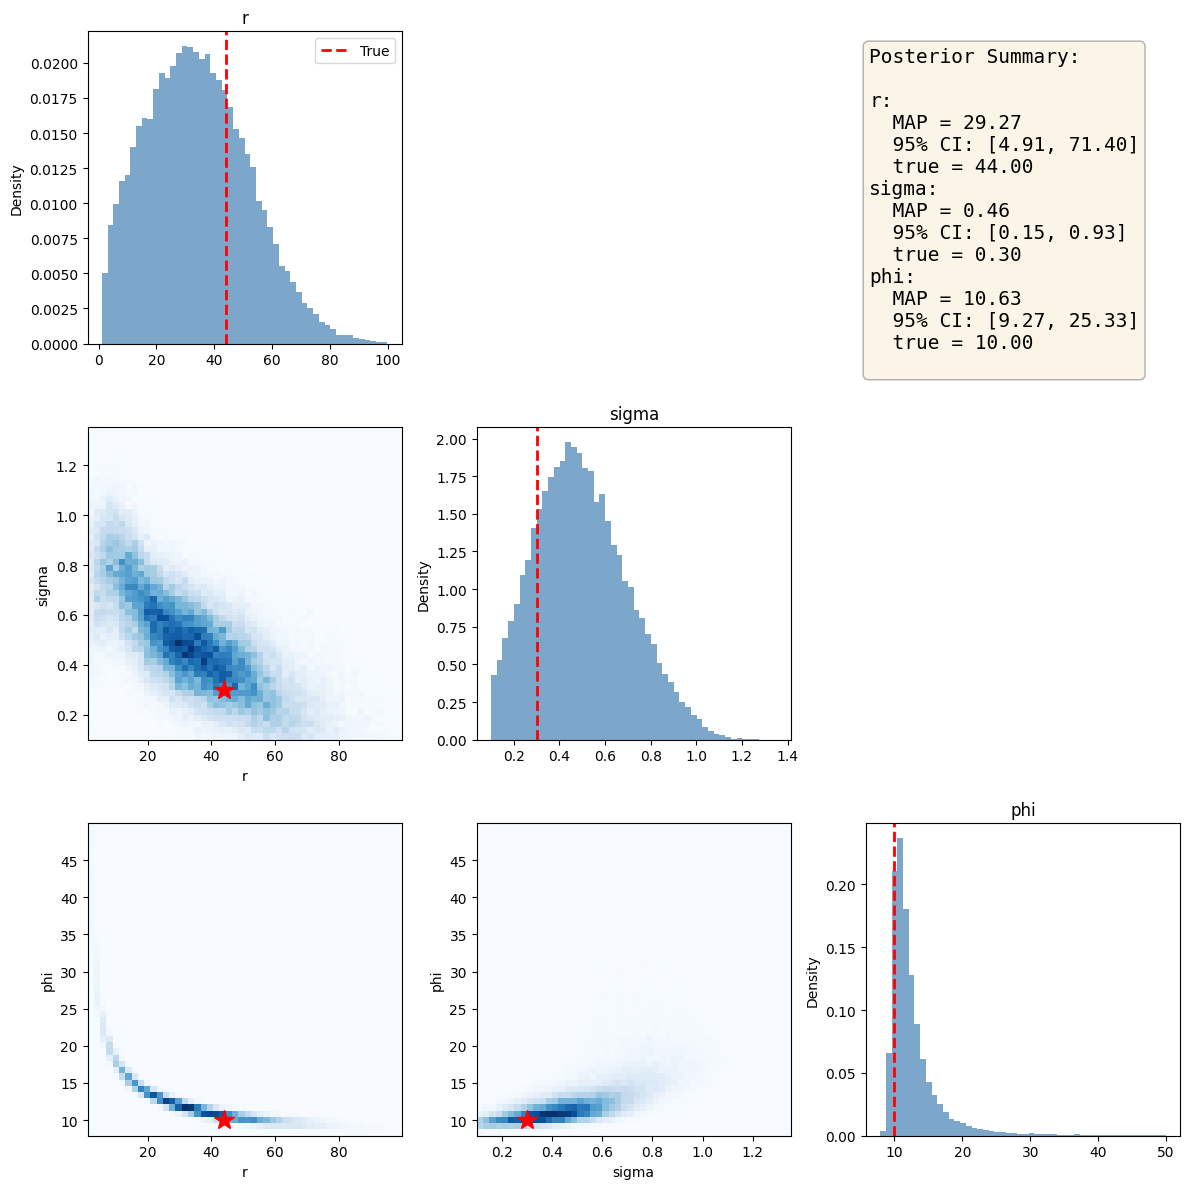

In [9]:
# Create a corner plot showing marginal and joint posteriors
make_plots = True
if make_plots:
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    param_names = ['r', 'sigma', 'phi']  
    samples_np = posterior_samples.cpu().numpy()

    for i in range(3):
        for j in range(3):
            ax = axes[i, j]
            
            if i == j:
                # Diagonal: marginal distributions
                ax.hist(samples_np[:, i], bins=50, density=True, alpha=0.7, color='steelblue')
                ax.axvline(true_theta[i].item(), color='red', linestyle='--', linewidth=2, label='True')
                ax.set_ylabel('Density')
                ax.set_title(f'{param_names[i]}')
                if i == 0:
                    ax.legend()
            elif i > j:
                # Lower triangle: 2D joint distributions
                ax.hist2d(samples_np[:, j], samples_np[:, i], bins=50, cmap='Blues', density=True)
                ax.plot(true_theta[j].item(), true_theta[i].item(), 'r*', markersize=15, label='True')
                ax.set_xlabel(param_names[j])
                ax.set_ylabel(param_names[i])
            else:
                # Upper triangle: add posterior summary text in top-right cell
                if i == 0 and j == 2:
                    ax.axis('off')
                    # Create summary text using MAP and credible intervals
                    summary_text = "Posterior Summary:\n\n"
                    for k, name in enumerate(param_names):
                        # Calculate MAP using histogram
                        counts, bin_edges = np.histogram(samples_np[:, k], bins=100)
                        map_val = (bin_edges[np.argmax(counts)] + bin_edges[np.argmax(counts) + 1]) / 2
                        
                        # Calculate 95% CI using percentiles
                        ci_lower = np.percentile(samples_np[:, k], 2.5)
                        ci_upper = np.percentile(samples_np[:, k], 97.5)
                        
                        true_val = true_theta[k].item()
                        summary_text += f"{name}:\n"
                        summary_text += f"  MAP = {map_val:.2f}\n"
                        summary_text += f"  95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]\n"
                        summary_text += f"  true = {true_val:.2f}\n"
                    
                    ax.text(0.01, 0.95, summary_text, 
                           transform=ax.transAxes,
                           verticalalignment='top',
                           fontsize=14,
                           family='monospace',
                           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
                else:
                    ax.axis('off')

    plt.tight_layout()

    save_fig(fig, 'RickerPosterior', CHAPTER, basedir=IMAGE_DIR)

    # plt.savefig(FIGURE_DIR / "ricker_model_posterior_corner_plot.png", dpi=300)
    plt.show()    

else:    # Still compute samples_np for use in later cells
    samples_np = posterior_samples.cpu().numpy()

## Step 9: Posterior Predictive Check

Generate simulations from the posterior samples and compare with the observed data.

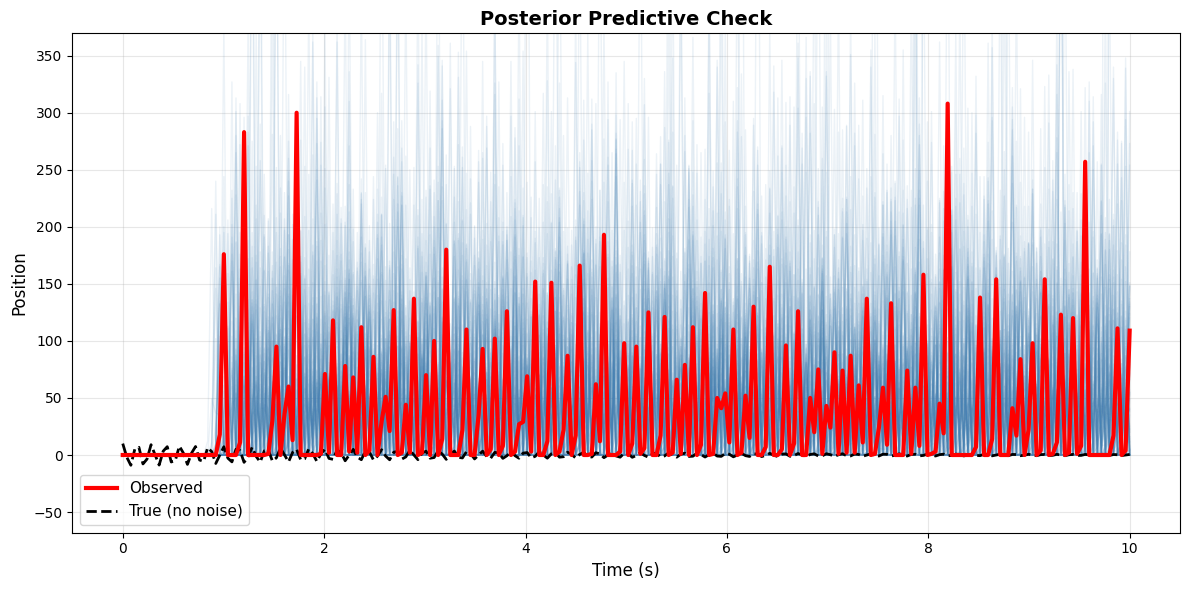

Posterior predictive check complete!
The blue shaded region shows simulations from posterior samples.
Good agreement indicates the posterior captures the observed dynamics.
Posterior predictive check skipped (plotting disabled).


In [10]:
# Posterior predictive check
if make_plots:
    n_pred_samples = 100
    pred_indices = np.random.choice(len(posterior_samples), n_pred_samples, replace=False)

    plt.figure(figsize=(12, 6))

    # Plot posterior predictive samples
    for idx in pred_indices:
        theta_sample = posterior_samples[idx]
        x_pred = ricker_simulator(theta_sample, t=t)
        plt.plot(t.numpy(), x_pred.numpy(), alpha=0.1, color='steelblue', linewidth=1)

    # Plot the observed data
    plt.plot(t.numpy(), x_obs.cpu().numpy(), color='red', linewidth=3, label='Observed', zorder=10)

    # Plot simulation with true parameters
    x_true = damped_oscillator_simulator(true_theta, t=t, noise_std=0.0)
    plt.plot(t.numpy(), x_true.cpu().numpy(), color='black', linewidth=2, 
             linestyle='--', label='True (no noise)', zorder=9)

    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Position', fontsize=12)
    plt.title('Posterior Predictive Check', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.ylim(top=1.2 * x_obs.max().item())
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Posterior predictive check complete!")
    print("The blue shaded region shows simulations from posterior samples.")

    print("Good agreement indicates the posterior captures the observed dynamics.")
    print("Posterior predictive check skipped (plotting disabled).")


## Step 10: Quantitative Evaluation

Calculate coverage and other metrics to evaluate the quality of the posterior.

In [11]:
# Calculate credible intervals
percentiles = [5, 25, 50, 75, 95]
param_names = ['r (growth rate)', 'sigma (growth noise)', 'phi (sampling noise)']

print("Posterior Credible Intervals:")
print("=" * 70)

for i, name in enumerate(param_names):
    quantiles = np.percentile(samples_np[:, i], percentiles)
    true_val = true_theta[i].item()
    
    # Check if true value is in 90% credible interval
    in_ci = quantiles[0] <= true_val <= quantiles[4]
    
    print(f"\n{name}:")
    print(f"  True value: {true_val:.3f}")
    print(f"  Posterior median: {quantiles[2]:.3f}")
    print(f"  50% CI: [{quantiles[1]:.3f}, {quantiles[3]:.3f}]")
    print(f"  90% CI: [{quantiles[0]:.3f}, {quantiles[4]:.3f}]")
    print(f"  True value in 90% CI: {'✓' if in_ci else '✗'}")

# Calculate mean absolute error
mae = np.abs(samples_np.mean(axis=0) - true_theta.numpy()).mean()
print(f"\n{'='*70}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"{'='*70}")

Posterior Credible Intervals:

r (growth rate):
  True value: 44.000
  Posterior median: 33.252
  50% CI: [20.877, 46.269]
  90% CI: [7.410, 65.211]
  True value in 90% CI: ✓

sigma (growth noise):
  True value: 0.300
  Posterior median: 0.482
  50% CI: [0.347, 0.631]
  90% CI: [0.186, 0.859]
  True value in 90% CI: ✓

phi (sampling noise):
  True value: 10.000
  Posterior median: 11.579
  50% CI: [10.477, 13.546]
  90% CI: [9.514, 20.502]
  True value in 90% CI: ✓

Mean Absolute Error (MAE): 4.2567


## Summary

This notebook demonstrated simulation-based inference for time series data using:

1. **Simulator**: A damped harmonic oscillator with noise
2. **Embedding Network**: CausalCNN to extract temporal features
3. **Inference**: Neural Posterior Estimation (NPE) with Masked Autoregressive Flows
4. **Validation**: Posterior predictive checks and credible intervals

### Key Advantages of SBI for Time Series:

- **Likelihood-free**: No need to derive analytical likelihood functions
- **Flexible**: Works with complex, high-dimensional simulators
- **Embedding networks**: Automatically learn relevant features from raw time series
- **Amortized inference**: Once trained, can quickly infer parameters for new observations

### Extensions to Try:

- Use `TransformerEmbedding` for longer-range dependencies
- Try multi-round inference for improved accuracy
- Apply to more complex dynamical systems (Lotka-Volterra, SIR models, etc.)
- Incorporate different noise models or missing data